In [16]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Parámetros del sistema
m = 20.0  # Masa (kg)[cite: 2]
k = 20.0  # Constante del resorte (N/m)
c_values = [5, 40, 200]  # Coeficientes de amortiguamiento en un array
labels = ['Subamortiguado (c=5)', 'Criticamente amortiguado (c=40)', 'Sobreamortiguado (c=200)']

In [ ]:
# Configuración del método numérico Range-Kutta
h = 0.05              # Tamaño del paso de integración
t = np.arange(0, 15 + h, h) # Vector de tiempo de 0 a 15 s[cite: 2]
N = len(t)            # Número total de puntos
plt.figure(figsize=(10, 6))

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

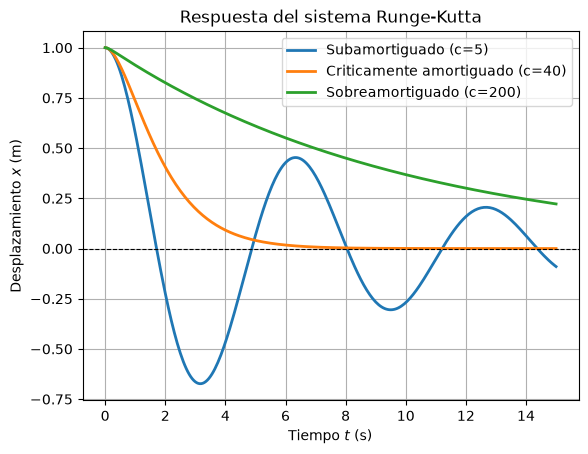

In [ ]:
# Bucle para iterar sobre cada valor de amortiguamiento, usando el arreglo de coeficientes de amortiguamiento y sus etiquetas correspondientes
for c, label in zip(c_values, labels):
    #Inicialización del vector de estado
    # Donde la fila 0 desplazamiento x1
    # la fila 1 es la velocidad x2
    x = np.zeros((2, N))
    x[:, 0] = [1.0, 0.0]  #Condiciones iniciales: x=1 m, velocidad=0 m/s

    # Definición del sistema de derivadas con variables de estado
    def sistema(t, y):
        x1, x2 = y
        dx1_dt = x2
        dx2_dt = -(k/m)*x1 - (c/m)*x2
        return np.array([dx1_dt, dx2_dt])

    # Bucle interno para el método Runge-Kutta
    for i in range(N - 1):
        y_actual = x[:, i]
        t_actual = t[i]
        
        # Cálculo de las 4 pendientes
        k1 = sistema(t_actual, y_actual)
        k2 = sistema(t_actual + h/2, y_actual + (h/2)*k1)
        k3 = sistema(t_actual + h/2, y_actual + (h/2)*k2)
        k4 = sistema(t_actual + h, y_actual + h*k3)
        
        # Cálculo del siguiente estado
        x[:, i+1] = y_actual + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
    
    # Gráfica del desplazamiento vs tiempo
    plt.plot(t, x[0, :], label=label, linewidth=2)
    
plt.title('Respuesta del sistema Runge-Kutta')
plt.xlabel('Tiempo $t$ (s)')
plt.ylabel('Desplazamiento $x$ (m)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()
plt.grid(True)
plt.show()